In [ ]:
#Si estás trabajando en Google Colab, ejecuta esta celda una sola vez para instalar las librerías
%pip install -q qiskit qiskit-aer pylatexenc

# Sesión 3 Laboratorio de Computación Cuántica 1

## Algebra Lineal para la computación cuántica en Numpy y Ejercicios de Qiskit y Numpy

En las primeras dos sesiones aprendimos las bases de Python y comenzamos a fabricar circuitos cuánticos con Qiskit. Pero para programar computación cuántica no basta con conocer la notación y la sintaxis: necesitamos conectar el código con las matrices, los vectores y los productos tensoriales que aparecen en la teoría.

Esta será una sesión dedicada principalmente a visualizar las herramientas matemáticas. Primero vamos a completar las herramientas de NumPy que necesitamos para traducir el álgebra lineal a código y visualizar como utilizar el algebra lineal de la computación cuántica en Numpy. Después veremos algunas herramientas de Qiskit que quedaron pendientes en la sesión anterior. Finalmente usaremos ambas librerías para resolver problemas relacionados con los temas vistos en clase.

## NumPy

Cuando nosotros escribimos un estado $|\psi\rangle$ o una compuerta $\hat{U}$, estamos usando una notación compacta para representar vectores y matrices. NumPy nos permite fabricar esos mismos objetos dentro de la computadora y operar con ellos.

La intención de esta sección no es aprender comandos aislados. Vamos a tomar cada concepto matemático, recordar qué significa y después ver cómo se representa con NumPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True) #Mostramos los resultados con cuatro decimales

print("Versión de NumPy:", np.__version__)

Versión de NumPy: 2.2.6


### Cheatsheet Básica de NumPy

Antes de comenzar con las matrices, aquí tienes una referencia rápida de las herramientas de NumPy que usaremos durante la sesión. No es necesario memorizarlas todas. La intención de esta cheatsheet es que puedas regresar a ella cuando no recuerdes cómo escribir una operación.

#### Números y Funciones Matemáticas

| Herramienta | ¿Para qué sirve? | Ejemplo |
|---|---|---|
| `np.pi` | Representa al número $\pi$. | `theta = np.pi/2` |
| `np.sqrt(x)` | Calcula la raíz cuadrada $\sqrt{x}$. | `np.sqrt(2)` |
| `np.sin(x)` | Calcula $\sin(x)$ usando radianes. | `np.sin(np.pi/2)` |
| `np.cos(x)` | Calcula $\cos(x)$ usando radianes. | `np.cos(np.pi)` |
| `np.tan(x)` | Calcula $\tan(x)$ usando radianes. | `np.tan(np.pi/4)` |
| `np.exp(x)` | Calcula la exponencial $e^x$. También acepta exponentes complejos. | `np.exp(1j*theta)` |
| `np.log(x)` | Calcula el logaritmo natural $\ln(x)$. | `np.log(np.e)` |
| `np.degrees(x)` | Convierte un ángulo de radianes a grados. | `np.degrees(np.pi)` |
| `np.radians(x)` | Convierte un ángulo de grados a radianes. | `np.radians(180)` |

La exponencial compleja aparece constantemente en computación cuántica debido a la fórmula de Euler:

$$
e^{i\theta}=\cos(\theta)+i\sin(\theta).
$$

#### Arreglos y Matrices

| Herramienta | ¿Para qué sirve? | Ejemplo |
|---|---|---|
| `np.array(datos)` | Fabrica un vector o una matriz. | `np.array([1, 0])` |
| `dtype=complex` | Permite almacenar números complejos en el arreglo. | `np.array([1, 1j], dtype=complex)` |
| `np.zeros(n)` | Fabrica un vector con todas sus entradas iguales a $0$. | `np.zeros(3)` |
| `np.ones(n)` | Fabrica un vector con todas sus entradas iguales a $1$. | `np.ones(3)` |
| `np.eye(n)` | Fabrica la matriz identidad $I_n$. | `np.eye(2)` |
| `np.diag(lista)` | Coloca las entradas de una lista sobre la diagonal. | `np.diag([1, -1])` |
| `np.arange(a,b)` | Fabrica valores enteros desde $a$ hasta antes de $b$. | `np.arange(0, 4)` |
| `np.linspace(a,b,n)` | Fabrica $n$ puntos igualmente espaciados entre $a$ y $b$. | `np.linspace(0, 2*np.pi, 5)` |
| `arreglo.shape` | Indica las dimensiones del arreglo. | `A.shape` |
| `arreglo.reshape(m,n)` | Reorganiza las entradas en una matriz de tamaño $m\times n$. | `v.reshape(2, 2)` |
| `np.sum(arreglo)` | Suma todas las entradas. | `np.sum(probabilidades)` |

#### Números Complejos

| Herramienta | ¿Para qué sirve? | Ejemplo |
|---|---|---|
| `z.real` | Recupera la parte real $\operatorname{Re}(z)$. | `(2+3j).real` |
| `z.imag` | Recupera la parte imaginaria $\operatorname{Im}(z)$. | `(2+3j).imag` |
| `np.conj(z)` | Calcula el conjugado $z^*$. | `np.conj(2+3j)` |
| `np.abs(z)` | Calcula el módulo $|z|$. | `np.abs(2+3j)` |
| `np.angle(z)` | Calcula el argumento $\arg(z)$ en radianes. | `np.angle(1+1j)` |

#### Comparaciones Numéricas

Las computadoras trabajan con aproximaciones decimales. Por esta razón, una operación que matemáticamente vale $0$ puede producir un número como $10^{-16}$.

| Herramienta | ¿Para qué sirve? | Ejemplo |
|---|---|---|
| `np.round(x,n)` | Redondea un resultado a $n$ decimales. | `np.round(x, 4)` |
| `np.isclose(a,b)` | Comprueba si dos números son aproximadamente iguales. | `np.isclose(a, b)` |
| `np.allclose(A,B)` | Comprueba si todas las entradas de dos arreglos son aproximadamente iguales. | `np.allclose(A, B)` |

#### Vectores, Matrices y Álgebra Lineal

| Herramienta | ¿Para qué sirve? | Representación matemática |
|---|---|---|
| `A@B` | Calcula el producto matricial. | $AB$ |
| `A@v` | Aplica una matriz sobre un vector. | $A\lvert v\rangle$ |
| `A.T` | Calcula la transpuesta. | $A^T$ |
| `A.conj().T` | Calcula la adjunta. | $A^\dagger$ |
| `np.linalg.norm(v)` | Calcula la norma de un vector. | $\left\lVert v\right\rVert$ |
| `np.vdot(v,w)` | Calcula el producto interno y conjuga el primer vector. | $\langle v\vert w\rangle$ |
| `np.outer(v,w.conj())` | Calcula el producto exterior. | $\lvert v\rangle\langle w\rvert$ |
| `np.kron(A,B)` | Calcula el producto de Kronecker. | $A\otimes B$ |
| `np.linalg.eig(A)` | Encuentra eigenvalores y eigenvectores de una matriz general. | $A\lvert v\rangle=\lambda\lvert v\rangle$ |
| `np.linalg.eigh(A)` | Encuentra eigenvalores y eigenvectores de una matriz hermitiana. | $A\lvert v\rangle=\lambda\lvert v\rangle$ |

In [2]:
#Ejemplos rápidos de la cheatsheet

theta_cheatsheet = np.pi/4 #Elegimos un ángulo de 45 grados

print("sen(theta) =", np.sin(theta_cheatsheet))
print("cos(theta) =", np.cos(theta_cheatsheet))
print("exp(i theta) =", np.exp(1j*theta_cheatsheet))
print("cos(theta)+i sen(theta) =", np.cos(theta_cheatsheet)+1j*np.sin(theta_cheatsheet))
print("¿Se cumple la fórmula de Euler?", np.allclose(
    np.exp(1j*theta_cheatsheet),
    np.cos(theta_cheatsheet)+1j*np.sin(theta_cheatsheet)
))

puntos_cheatsheet = np.linspace(0, 2*np.pi, 5) #Fabricamos cinco ángulos entre 0 y 2 pi
identidad_cheatsheet = np.eye(2, dtype=complex) #Fabricamos la identidad de tamaño 2 x 2

print("\nCinco ángulos:", puntos_cheatsheet)
print("\nIdentidad:\n", identidad_cheatsheet)

sen(theta) = 0.7071067811865476
cos(theta) = 0.7071067811865476
exp(i theta) = (0.7071067811865476+0.7071067811865476j)
cos(theta)+i sen(theta) = (0.7071067811865476+0.7071067811865476j)
¿Se cumple la fórmula de Euler? True

Cinco ángulos: [0.     1.5708 3.1416 4.7124 6.2832]

Identidad:
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


### Matrices

Una matriz es un arreglo rectangular de números organizado en renglones y columnas. De manera intuitiva, una matriz es una regla que recibe un vector y lo transforma en otro vector.

Una matriz con $m$ renglones y $n$ columnas tiene la forma

$$
A=
\begin{pmatrix}
a_{11}&a_{12}&\cdots&a_{1n}\\
a_{21}&a_{22}&\cdots&a_{2n}\\
\vdots&\vdots&\ddots&\vdots\\
a_{m1}&a_{m2}&\cdots&a_{mn}
\end{pmatrix}.
$$

Decimos que $A$ tiene tamaño $m\times n$. La entrada $a_{ij}$ se encuentra en el renglón $i$ y la columna $j$.

A mi personalmente me gusta recordar el orden de las entradas utilizando la nomenclatura FC de Facultad de Ciencias, porque F significa filas y C columnas.

En computación cuántica trabajamos principalmente con matrices cuadradas, es decir, matrices con el mismo número de renglones y columnas. Una compuerta de un qubit se representa con una matriz de tamaño $2\times2$ y una compuerta de dos qubits con una matriz de tamaño $4\times4$ y compuertas mas grandes como $2^n \times 2^n$.

#### Recordatorio: Matrices de Pauli

Antes de aprender a fabricar matrices con NumPy, vale la pena recordar las tres matrices de Pauli que utilizaremos constantemente en computación cuántica:

$$
X=
\begin{pmatrix}
0&1\\
1&0
\end{pmatrix},
\qquad
Y=
\begin{pmatrix}
0&-i\\
i&0
\end{pmatrix},
\qquad
Z=
\begin{pmatrix}
1&0\\
0&-1
\end{pmatrix}.
$$

La matriz $X$ intercambia los estados de la base computacional:

$$
X|0\rangle=|1\rangle,
\qquad
X|1\rangle=|0\rangle.
$$

Por esta razón podemos pensar en $X$ como un cambio de bit cuántico.

La matriz $Z$ conserva $|0\rangle$ y cambia el signo de $|1\rangle$:

$$
Z|0\rangle=|0\rangle,
\qquad
Z|1\rangle=-|1\rangle.
$$

Por esta razón decimos que $Z$ produce un cambio de fase.

La matriz $Y$ combina un intercambio de los estados con factores de fase complejos:

$$
Y|0\rangle=i|1\rangle,
\qquad
Y|1\rangle=-i|0\rangle.
$$

Las tres matrices son hermitianas y unitarias:

$$
X^\dagger=X,
\qquad
Y^\dagger=Y,
\qquad
Z^\dagger=Z,
$$

$$
X^2=Y^2=Z^2=I.
$$

Más adelante utilizaremos estas matrices para transformar vectores, construir productos tensoriales, encontrar eigenvalores y describir circuitos cuánticos.

### Crear Matrices con NumPy

En NumPy usamos `np.array` para fabricar una matriz. Cada lista interna representa un renglón.

La herramienta `shape` nos dice el tamaño de la matriz y `dtype` nos dice qué tipo de números puede almacenar. Como las amplitudes y las compuertas cuánticas pueden tener números complejos, usaremos `dtype=complex`.

Veamos cómo fabricar la matriz

$$
A=
\begin{pmatrix}
1&i\\
-i&2
\end{pmatrix}.
$$

In [3]:
A = np.array([
    [1, 1j],
    [-1j, 2]
], dtype=complex) #Fabricamos una matriz de tamaño 2 x 2 con entradas complejas. Fijate como acoplamos multiples listas en un solo np.array

print("A =\n", A)   #Si te interesa, el caracter \n lo que hace es que genera un nuevo renglon en la impresion
print("\nTamaño de A:", A.shape)
print("Tipo de entradas:", A.dtype)
print("Entrada del primer renglón y segunda columna:", A[0, 1])

A =
 [[ 1.+0.j  0.+1.j]
 [-0.-1.j  2.+0.j]]

Tamaño de A: (2, 2)
Tipo de entradas: complex128
Entrada del primer renglón y segunda columna: 1j


Hay matrices que aparecen constantemente en computación cuantica y Numpy nos permite fabricarlas de manera directa.

La matriz cero tiene todas sus entradas iguales a $0$. La matriz identidad tiene $1$ en la diagonal y $0$ en el resto de sus entradas:

$$
I_n=
\begin{pmatrix}
1&0&\cdots&0\\
0&1&\cdots&0\\
\vdots&\vdots&\ddots&\vdots\\
0&0&\cdots&1
\end{pmatrix}.
$$

La identidad cumple

$$
I_n|v\rangle=|v\rangle.
$$

`np.zeros` fabrica una matriz cero, `np.eye` fabrica la identidad y `np.diag` fabrica una matriz diagonal.

In [4]:
matriz_cero = np.zeros((2, 3), dtype=complex) #Fabricamos una matriz cero de tamaño 2 x 3
I = np.eye(2, dtype=complex) #Fabricamos la identidad de tamaño 2 x 2
D = np.diag([1, -1, 1j]).astype(complex) #Colocamos tres números sobre la diagonal

print("Matriz cero:\n", matriz_cero)
print("\nIdentidad:\n", I)
print("\nMatriz diagonal:\n", D)

Matriz cero:
 [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]]

Identidad:
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Matriz diagonal:
 [[ 1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+1.j]]


### Números Complejos dentro de las Matrices

¿Por qué indicamos que nuestras matrices pueden tener entradas complejas? Recordemos que un número complejo tiene la forma

$$
z=a+ib,
$$

donde $a,b\in\mathbb{R}$ y $i^2=-1$.

Su conjugado y su módulo son

$$
z^*=a-ib,
\qquad
|z|=\sqrt{a^2+b^2}.
$$

También podemos escribirlo en forma polar:

$$
z=|z|e^{i\theta},
$$

donde $\theta=\arg(z)$. En Python escribimos la unidad imaginaria como `1j`.

Los números complejos aparecen tanto en las amplitudes como en las compuertas. Por ejemplo, las matrices de Pauli $Y$ y de fase $S$ son

$$
Y=
\begin{pmatrix}
0&-i\\
i&0
\end{pmatrix},
\qquad
S=
\begin{pmatrix}
1&0\\
0&i
\end{pmatrix}.
$$

In [5]:
z = -1 - 1j #Fabricamos el número complejo z=-1-i

print("Parte real:", z.real)
print("Parte imaginaria:", z.imag)
print("Conjugado:", np.conj(z))
print("Módulo:", np.abs(z))
print("Argumento:", np.angle(z))
print("Reconstrucción polar:", np.abs(z)*np.exp(1j*np.angle(z)))

Parte real: -1.0
Parte imaginaria: -1.0
Conjugado: (-1+1j)
Módulo: 1.4142135623730951
Argumento: -2.356194490192345
Reconstrucción polar: (-1-1.0000000000000002j)


Para una matriz compleja no basta con tomar la transpuesta. La adjunta o matriz tras el operador hermitiano se obtiene conjugando cada entrada y después intercambiando renglones por columnas:

$$
A^\dagger=(A^*)^T.
$$

En NumPy, `A.conj()` calcula $A^*$, `A.T` calcula $A^T$ y `A.conj().T` calcula $A^\dagger$.

Esta operación será importante porque una compuerta cuántica debe ser unitaria:

$$
U^\dagger U=I.
$$

In [6]:
Y = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

S = np.diag([1, 1j]).astype(complex)

print("Y^dagger =\n", Y.conj().T)  #Obtenemos la compuesta conjugada
print("\n¿Y es hermitiana?", np.allclose(Y.conj().T, Y)) #Verificamos que la matriz Y y su adjunta sean iguales
print("¿Y es unitaria?", np.allclose(Y.conj().T@Y, I)) #Verificamos que la matriz Y y su adjunta sean inversas 
print("¿S es hermitiana?", np.allclose(S.conj().T, S)) #Verificamos que la matriz S y su adjunta sean iguales
print("¿S es unitaria?", np.allclose(S.conj().T@S, I))#Verificamos que la matriz s y su adjunta sean inversas 

Y^dagger =
 [[ 0.-0.j  0.-1.j]
 [-0.+1.j  0.-0.j]]

¿Y es hermitiana? True
¿Y es unitaria? True
¿S es hermitiana? False
¿S es unitaria? True


### Multiplicación de Matrices

Sean $A$ una matriz de tamaño $m\times n$ y $B$ una matriz de tamaño $n\times p$. Podemos multiplicarlas porque el número de columnas de $A$ coincide con el número de renglones de $B$.

El producto $AB$ es una matriz de tamaño $m\times p$ cuyas entradas son

$$
(AB)_{ij}=\sum_{k=1}^{n}A_{ik}B_{kj}.
$$

Esto significa que para obtener una entrada del resultado multiplicamos un renglón de $A$ por una columna de $B$ y sumamos los productos.

En NumPy usamos `A@B` para el producto matricial. Es importante no confundirlo con `A*B`, pues `A*B` multiplica únicamente las entradas que ocupan la misma posición.

In [7]:
A = np.array([
    [1, 1j],
    [-1j, 2]
], dtype=complex)

B = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

producto_entrada_a_entrada = A*B #Multiplicamos entradas que ocupan la misma posición.NO CONFUNDIR CON EL PRODUCTO MATRICIAL
producto_matricial = A@B #Calculamos el producto matricial AB

print("A*B =\n", producto_entrada_a_entrada)
print("\nA@B =\n", producto_matricial)

A*B =
 [[0.+0.j 0.+1.j]
 [0.-1.j 0.+0.j]]

A@B =
 [[0.+1.j 1.+0.j]
 [2.+0.j 0.-1.j]]


La multiplicación de matrices no es conmutativa. En general,

$$
AB\neq BA.
$$

Esto tiene una consecuencia directa para los circuitos cuánticos: cambiar el orden de las compuertas puede cambiar por completo el estado final.

Vamos a comprobarlo con las matrices de Pauli $X$ y $Z$.

In [8]:
X = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

Z = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

XZ = X@Z #Aplicamos primero Z y después X
ZX = Z@X #Aplicamos primero X y después Z

print("XZ =\n", XZ)
print("\nZX =\n", ZX)
print("\n¿XZ=ZX?", np.allclose(XZ, ZX))
print("¿XZ=-ZX?", np.allclose(XZ, -ZX))

XZ =
 [[ 0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j]]

ZX =
 [[ 0.+0.j  1.+0.j]
 [-1.+0.j  0.+0.j]]

¿XZ=ZX? False
¿XZ=-ZX? True


### Operaciones de Matrices sobre Vectores

Un vector columna de dimensión $n$ se puede escribir como

$$
|v\rangle=
\begin{pmatrix}
v_1\\
v_2\\
\vdots\\
v_n
\end{pmatrix}.
$$

Si $A$ es una matriz de tamaño $m\times n$, entonces $A|v\rangle$ es un nuevo vector de dimensión $m$:

$$
(A|v\rangle)_i=\sum_{j=1}^{n}A_{ij}v_j.
$$

De manera intuitiva, la matriz toma al vector y lo transforma. En NumPy representamos al vector con `np.array` y calculamos la transformación con `A@v`.

Antes de seguir, vale la pena recordar las dos bases que utilizaremos con mayor frecuencia.

La base computacional, que también es la base de eigenvectores de $Z$, es

$$
\mathcal{B}_Z=\{|0\rangle,|1\rangle\},
$$

donde

$$
|0\rangle=
\begin{pmatrix}
1\\
0
\end{pmatrix},
\qquad
|1\rangle=
\begin{pmatrix}
0\\
1
\end{pmatrix}.
$$

La base diagonal, que es la base de eigenvectores de $X$, es

$$
\mathcal{B}_X=\{|+\rangle,|-\rangle\},
$$

donde

$$
|+\rangle
=\frac{|0\rangle+|1\rangle}{\sqrt{2}}
=\frac{1}{\sqrt{2}}
\begin{pmatrix}
1\\
1
\end{pmatrix},
$$

$$
|-\rangle
=\frac{|0\rangle-|1\rangle}{\sqrt{2}}
=\frac{1}{\sqrt{2}}
\begin{pmatrix}
1\\
-1
\end{pmatrix}.
$$

La compuerta Hadamard nos permite pasar de una base a la otra:

$$
H|0\rangle=|+\rangle,
\qquad
H|1\rangle=|-\rangle,
$$

$$
H|+\rangle=|0\rangle,
\qquad
H|-\rangle=|1\rangle.
$$

In [9]:
ket0 = np.array([1, 0], dtype=complex) #Representamos |0>
ket1 = np.array([0, 1], dtype=complex) #Representamos |1>

X_ket0 = X@ket0 #Aplicamos X sobre |0>
Z_ket1 = Z@ket1 #Aplicamos Z sobre |1>

print("X|0> =", X_ket0)
print("¿X|0>=|1>?", np.allclose(X_ket0, ket1))
print("\nZ|1> =", Z_ket1)
print("¿Z|1>=-|1>?", np.allclose(Z_ket1, -ket1))

X|0> = [0.+0.j 1.+0.j]
¿X|0>=|1>? True

Z|1> = [ 0.+0.j -1.+0.j]
¿Z|1>=-|1>? True


La compuerta Hadamard se representa con

$$
H=\frac{1}{\sqrt{2}}
\begin{pmatrix}
1&1\\
1&-1
\end{pmatrix}.
$$

Al aplicarla sobre $|0\rangle$ obtenemos

$$
H|0\rangle
=\frac{|0\rangle+|1\rangle}{\sqrt{2}}
=|+\rangle.
$$

Las entradas de un estado son amplitudes. Si

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle,
$$

entonces las probabilidades de medición son $|\alpha|^2$ y $|\beta|^2$. Por eso los números complejos entran de manera natural en la teoría: necesitamos el módulo cuadrado de cada amplitud para obtener una probabilidad real.

In [10]:
H = np.array([
    [1, 1],
    [1, -1]
], dtype=complex)/np.sqrt(2)

ket_plus = H@ket0 #Aplicamos Hadamard sobre |0>
probabilidades_plus = np.abs(ket_plus)**2 #Calculamos el módulo cuadrado de cada amplitud

print("H|0> =", ket_plus)
print("Probabilidades:", probabilidades_plus)
print("Suma de probabilidades:", np.sum(probabilidades_plus))

H|0> = [0.7071+0.j 0.7071+0.j]
Probabilidades: [0.5 0.5]
Suma de probabilidades: 0.9999999999999998


La norma de un estado se define como

$$
\left\lVert\psi\right\rVert
=\sqrt{\langle\psi|\psi\rangle}.
$$

Un estado cuántico debe cumplir $\left\lVert\psi\right\rVert=1$. `np.linalg.norm` calcula la norma y `np.vdot(psi,phi)` calcula el producto interno $\langle\psi|\phi\rangle$, conjugando correctamente el primer vector.

Como las compuertas cuánticas son unitarias, conservan la norma:

$$
\left\lVert U|\psi\rangle\right\rVert
=\left\lVert|\psi\rangle\right\rVert.
$$

In [11]:
psi = np.array([np.sqrt(3)/2, 1j/2], dtype=complex) #Fabricamos un estado con amplitudes complejas
H_psi = H@psi #Aplicamos una matriz unitaria

print("Norma de |psi>:", np.linalg.norm(psi))
print("Producto interno <psi|psi>:", np.vdot(psi, psi))
print("Norma de H|psi>:", np.linalg.norm(H_psi))
print("¿La norma se conserva?", np.isclose(np.linalg.norm(psi), np.linalg.norm(H_psi)))

Norma de |psi>: 0.9999999999999999
Producto interno <psi|psi>: (0.9999999999999999+0j)
Norma de H|psi>: 0.9999999999999999
¿La norma se conserva? True


### Productos Internos, Productos Exteriores y Proyectores

Hasta ahora hemos representado los kets como vectores. El bra asociado a un ket se obtiene tomando su adjunta:

$$
|\psi\rangle=
\begin{pmatrix}
\alpha\\
\beta
\end{pmatrix}
\quad\Longrightarrow\quad
\langle\psi|=
\begin{pmatrix}
\alpha^*&\beta^*
\end{pmatrix}.
$$

El producto interno de dos estados es un número complejo:

$$
\langle\psi|\phi\rangle
=\sum_k\psi_k^*\phi_k.
$$

Este producto nos permite estudiar la norma y la ortogonalidad. Dos estados son ortogonales si

$$
\langle\psi|\phi\rangle=0.
$$

En NumPy usamos `np.vdot(psi,phi)`. Esta herramienta conjuga el primer vector, tal como lo exige la definición matemática.

In [12]:
ket_minus = (ket0-ket1)/np.sqrt(2) #Fabricamos |->

producto_plus_minus = np.vdot(ket_plus, ket_minus) #Calculamos <+|->
producto_plus_plus = np.vdot(ket_plus, ket_plus) #Calculamos <+|+>

print("<+|-> =", producto_plus_minus)
print("¿|+> y |-> son ortogonales?", np.isclose(producto_plus_minus, 0))
print("<+|+> =", producto_plus_plus)

<+|-> = 0j
¿|+> y |-> son ortogonales? True
<+|+> = (0.9999999999999998+0j)


El producto exterior se construye en el orden contrario:

$$
|\psi\rangle\langle\phi|.
$$

Ahora el resultado no es un número, sino una matriz. NumPy lo calcula con `np.outer(psi,phi.conj())`.

Un caso especialmente importante aparece cuando usamos el mismo estado en ambos lados:

$$
P_\psi=|\psi\rangle\langle\psi|.
$$

Esta matriz es el proyector sobre $|\psi\rangle$ y cumple

$$
P_\psi^2=P_\psi.
$$

Los proyectores conectan esta operación con el postulado de medición. Si el sistema se encuentra en $|\phi\rangle$, la probabilidad asociada a $P_\psi$ es

$$
p(\psi)=\langle\phi|P_\psi|\phi\rangle.
$$

In [13]:
P_plus = np.outer(ket_plus, ket_plus.conj()) #Fabricamos el proyector |+><+|
P_minus = np.outer(ket_minus, ket_minus.conj()) #Fabricamos el proyector |-><-|

probabilidad_plus = np.vdot(psi, P_plus@psi).real #Calculamos <psi|P_+|psi>
probabilidad_minus = np.vdot(psi, P_minus@psi).real #Calculamos <psi|P_-|psi>

print("P_+ =\n", P_plus)
print("\n¿P_+^2=P_+?", np.allclose(P_plus@P_plus, P_plus))
print("¿P_++P_-=I?", np.allclose(P_plus+P_minus, I))
print("\nProbabilidad de +:", probabilidad_plus)
print("Probabilidad de -:", probabilidad_minus)
print("Suma de probabilidades:", probabilidad_plus+probabilidad_minus)

P_+ =
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

¿P_+^2=P_+? True
¿P_++P_-=I? True

Probabilidad de +: 0.4999999999999998
Probabilidad de -: 0.4999999999999998
Suma de probabilidades: 0.9999999999999996


### Producto Tensorial

Hasta ahora trabajamos con un solo sistema. Pero si tenemos dos qubits, necesitamos una forma de combinar sus espacios y sus estados. Para ello usamos el producto tensorial.

Si $|a\rangle\in\mathcal{H}_A$ y $|b\rangle\in\mathcal{H}_B$, entonces

$$
|a\rangle\otimes|b\rangle
\in
\mathcal{H}_A\otimes\mathcal{H}_B.
$$

La dimensión del espacio compuesto es el producto de las dimensiones:

$$
\dim(\mathcal{H}_A\otimes\mathcal{H}_B)
=\dim(\mathcal{H}_A)\dim(\mathcal{H}_B).
$$

Dos qubits viven en un espacio de dimensión $2\times2=4$. Sus estados base se obtienen con

$$
|00\rangle=|0\rangle\otimes|0\rangle,
\quad
|01\rangle=|0\rangle\otimes|1\rangle,
$$

$$
|10\rangle=|1\rangle\otimes|0\rangle,
\quad
|11\rangle=|1\rangle\otimes|1\rangle.
$$

NumPy calcula el producto tensorial mediante el producto de Kronecker con `np.kron`.

In [14]:
ket00 = np.kron(ket0, ket0) #Calculamos |0> tensor |0>
ket01 = np.kron(ket0, ket1) #Calculamos |0> tensor |1>
ket10 = np.kron(ket1, ket0) #Calculamos |1> tensor |0>
ket11 = np.kron(ket1, ket1) #Calculamos |1> tensor |1>

print("|00> =", ket00)
print("|01> =", ket01)
print("|10> =", ket10)
print("|11> =", ket11)

|00> = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
|01> = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
|10> = [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
|11> = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]


Para matrices, el producto tensorial se representa como una matriz por bloques. Si

$$
A=
\begin{pmatrix}
a_{11}&a_{12}\\
a_{21}&a_{22}
\end{pmatrix},
$$

entonces

$$
A\otimes B=
\begin{pmatrix}
a_{11}B&a_{12}B\\
a_{21}B&a_{22}B
\end{pmatrix}.
$$

Si $A$ tiene tamaño $m\times n$ y $B$ tiene tamaño $p\times q$, entonces $A\otimes B$ tiene tamaño $mp\times nq$.

Por ejemplo, $H\otimes H$ es una matriz de tamaño $4\times4$ que aplica Hadamard a cada uno de los dos qubits.

In [15]:
HH = np.kron(H, H) #Fabricamos H tensor H
estado_superposicion = HH@ket00 #Aplicamos Hadamard a los dos factores de |00>

print("H tensor H =\n", HH)
print("\nTamaño:", HH.shape)
print("\n(H tensor H)|00> =", estado_superposicion)
print("Probabilidades:", np.abs(estado_superposicion)**2)

H tensor H =
 [[ 0.5+0.j  0.5+0.j  0.5+0.j  0.5+0.j]
 [ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]
 [ 0.5+0.j  0.5+0.j -0.5+0.j -0.5+0.j]
 [ 0.5+0.j -0.5+0.j -0.5+0.j  0.5-0.j]]

Tamaño: (4, 4)

(H tensor H)|00> = [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
Probabilidades: [0.25 0.25 0.25 0.25]


El producto tensorial también nos permite separar la acción de los operadores. Se cumple que

$$
(A\otimes B)(|a\rangle\otimes|b\rangle)
=(A|a\rangle)\otimes(B|b\rangle).
$$

Esto nos dice que aplicar $A\otimes B$ sobre el sistema completo es equivalente a aplicar $A$ al primer sistema, aplicar $B$ al segundo sistema y después combinar los resultados.

Vamos a comprobarlo con $X\otimes H$.

In [16]:
lado_izquierdo = np.kron(X, H)@np.kron(ket0, ket1) #Aplicamos el operador al sistema completo
lado_derecho = np.kron(X@ket0, H@ket1) #Aplicamos cada operador a su propio factor

print("Lado izquierdo:", lado_izquierdo)
print("Lado derecho:", lado_derecho)
print("¿Los resultados coinciden?", np.allclose(lado_izquierdo, lado_derecho))

Lado izquierdo: [ 0.    +0.j  0.    +0.j  0.7071+0.j -0.7071+0.j]
Lado derecho: [ 0.    +0.j -0.    +0.j  0.7071+0.j -0.7071+0.j]
¿Los resultados coinciden? True


El producto tensorial se dice que es bilineal. En cristiano: cada una de las entradas del producto tensorial cumplen condiciones de linealidad. Visualizalo,

$$
(\alpha|a\rangle+\beta|c\rangle)\otimes|b\rangle
=\alpha(|a\rangle\otimes|b\rangle)
+\beta(|c\rangle\otimes|b\rangle).
$$

Además, si los estados están normalizados, entonces

$$
\left\lVert|a\rangle\otimes|b\rangle\right\rVert
=\left\lVert|a\rangle\right\rVert
\left\lVert|b\rangle\right\rVert
=1.
$$

Precisamente con la ayuda del producto tensorial nosotros vamos a fabricar sistemas de muchos qubits.

Estas propiedades son las que permiten construir sistemas de varios qubits a partir de sistemas individuales.

In [17]:
alpha = 2-1j
beta = -1j
a = ket0
b = ket_plus
c = ket1

bilineal_izquierda = np.kron(alpha*a+beta*c, b)
bilineal_derecha = alpha*np.kron(a, b)+beta*np.kron(c, b)

print("¿Se cumple la bilinealidad?", np.allclose(bilineal_izquierda, bilineal_derecha))
print("Norma de |0> tensor |+>:", np.linalg.norm(np.kron(ket0, ket_plus)))

¿Se cumple la bilinealidad? True
Norma de |0> tensor |+>: 0.9999999999999999


### Eigenvalores y Eigenvectores

¿Qué ocurre si una matriz actúa sobre un vector y no cambia su dirección? Un vector no nulo $|v\rangle$ es un eigenvector de una matriz $A$ si existe un número $\lambda$ tal que

$$
A|v\rangle=\lambda|v\rangle.
$$

El número $\lambda$ es el eigenvalor asociado. La matriz puede estirar al vector, reducirlo o cambiar su fase, pero no lo saca de la dirección definida por $|v\rangle$.

Para encontrar los eigenvalores resolvemos

$$
\det(A-\lambda I)=0.
$$

En mecánica cuántica, los observables son matrices hermitianas. Puedes demostrar que para toda matriz hermitiana, sus eigenvalores son reales y representan los posibles resultados de una medición. Con esto decimos que representan observables, es decir, estados que dicen información física de un sistema. Sus eigenvectores representan los estados en los que esos resultados están bien definidos.

NumPy tiene dos herramientas principales para este problema. `np.linalg.eig` trabaja con matrices cuadradas generales, mientras que `np.linalg.eigh` aprovecha que una matriz es hermitiana.

Como las matrices de Pauli son hermitianas, usaremos `np.linalg.eigh`. Esta herramienta devuelve dos objetos: un arreglo con los eigenvalores y una matriz que contiene los eigenvectores en sus columnas.

Vamos a encontrar los eigenvalores de $X$, $Y$ y $Z$.

In [18]:
matrices_pauli = {"X": X, "Y": Y, "Z": Z}

for nombre, pauli in matrices_pauli.items():
    eigenvalores, eigenvectores = np.linalg.eigh(pauli) #Encontramos eigenvalores y eigenvectores
    print("\nMatriz", nombre)
    print("Eigenvalores:", eigenvalores)
    print("Eigenvectores en columnas:\n", eigenvectores)


Matriz X
Eigenvalores: [-1.  1.]
Eigenvectores en columnas:
 [[-0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j  0.7071+0.j]]

Matriz Y
Eigenvalores: [-1.  1.]
Eigenvectores en columnas:
 [[-0.7071+0.j     -0.7071+0.j    ]
 [ 0.    +0.7071j  0.    -0.7071j]]

Matriz Z
Eigenvalores: [-1.  1.]
Eigenvectores en columnas:
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]


Las tres matrices de Pauli tienen los mismos eigenvalores:

$$
\lambda_-= -1,
\qquad
\lambda_+=1.
$$

Pero sus eigenvectores son diferentes. Por ejemplo, para $X$ los eigenvectores son $|-\rangle$ y $|+\rangle$, mientras que para $Z$ son $|1\rangle$ y $|0\rangle$, dependiendo del orden en el que NumPy entregue los eigenvalores.

El orden puede cambiar y la fase global de cada eigenvector no es única. Por ello, la forma correcta de verificar el resultado es comprobar

$$
A|v_k\rangle=\lambda_k|v_k\rangle.
$$

In [19]:
for nombre, pauli in matrices_pauli.items():
    eigenvalores, eigenvectores = np.linalg.eigh(pauli)
    
    for columna, eigenvalor in enumerate(eigenvalores):
        eigenvector = eigenvectores[:, columna] #Tomamos el eigenvector de la columna correspondiente
        verificacion = np.allclose(pauli@eigenvector, eigenvalor*eigenvector) #Comprobamos A|v>=lambda|v>
        print(nombre, "| Eigenvalor:", eigenvalor, "| Verificación:", verificacion)

X | Eigenvalor: -1.0 | Verificación: True
X | Eigenvalor: 1.0 | Verificación: True
Y | Eigenvalor: -1.0 | Verificación: True
Y | Eigenvalor: 1.0 | Verificación: True
Z | Eigenvalor: -1.0 | Verificación: True
Z | Eigenvalor: 1.0 | Verificación: True


### Circuitos Cuánticos como Operaciones de Matrices

Antes de describir un circuito con matrices, vale la pena recordar cómo evolucionan los sistemas cuánticos.

Mientras el sistema se encuentra aislado y no realizamos una medición, su evolución está descrita por un operador unitario $U$. Si el estado inicial es $|\psi_{\mathrm{inicial}}\rangle$, entonces el estado después de la evolución es

$$
|\psi_{\mathrm{final}}\rangle
=U|\psi_{\mathrm{inicial}}\rangle.
$$

Un operador es unitario si satisface

$$
U^\dagger U=UU^\dagger=I.
$$

Esto también significa que su inversa es su adjunta:

$$
U^{-1}=U^\dagger.
$$

¿Por qué necesitamos que la evolución sea unitaria? Porque un operador unitario conserva el producto interno y, por lo tanto, conserva la norma del estado:

$$
\langle\psi_{\mathrm{final}}|\psi_{\mathrm{final}}\rangle
=\langle\psi_{\mathrm{inicial}}|U^\dagger U|\psi_{\mathrm{inicial}}\rangle
=\langle\psi_{\mathrm{inicial}}|\psi_{\mathrm{inicial}}\rangle
=1.
$$

Conservar la norma significa conservar la probabilidad total:

$$
\sum_x |\alpha_x|^2=1.
$$

Por esta razón, cada compuerta cuántica se representa mediante una matriz unitaria. Además, como $U^{-1}=U^\dagger$, toda evolución unitaria puede deshacerse aplicando su operación inversa.

Un circuito cuántico es una sucesión de estas operaciones unitarias. Si aplicamos primero $U_1$, después $U_2$ y finalmente $U_3$, el estado final es

$$
|\psi_{\mathrm{final}}\rangle
=U_3U_2U_1|\psi_{\mathrm{inicial}}\rangle.
$$

La matriz que actúa primero aparece a la derecha. Esta regla es muy importante al traducir un diagrama de circuito a una expresión matemática.

Veamos un circuito sencillo. Partimos de $|0\rangle$ y aplicamos $H$, después $Z$ y finalmente $H$:

$$
|\psi_{\mathrm{final}}\rangle=HZH|0\rangle.
$$

In [20]:
U_circuito_1 = H@Z@H #La operación que actúa primero aparece a la derecha
estado_circuito_1 = U_circuito_1@ket0 #Aplicamos la matriz total sobre |0>

print("Matriz total HZH:\n", U_circuito_1)
print("\nEstado final:", estado_circuito_1)
print("¿HZH coincide con X?", np.allclose(U_circuito_1, X))
print("¿El estado final es |1>?", np.allclose(estado_circuito_1, ket1))

Matriz total HZH:
 [[-0.+0.j  1.+0.j]
 [ 1.+0.j -0.+0.j]]

Estado final: [-0.+0.j  1.+0.j]
¿HZH coincide con X? True
¿El estado final es |1>? True


Ahora vamos a describir un circuito de dos qubits. Partimos de $|00\rangle$, aplicamos $H$ sobre `q0` y después aplicamos una compuerta controlada $\operatorname{CX}(q0,q1)$.

Qiskit escribe los estados de dos qubits en el orden

$$
|q_1q_0\rangle.
$$

Por ello, aplicar $H$ sobre `q0` corresponde a

$$
I\otimes H.
$$

La matriz total del circuito es

$$
U_{\mathrm{Bell}}
=\operatorname{CNOT}_{0\rightarrow1}(I\otimes H).
$$

In [21]:
H_sobre_q0 = np.kron(I, H) #Aplicar H sobre q0 corresponde a I tensor H

CNOT_q0_q1 = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0]
], dtype=complex) #CX con control q0 y objetivo q1 en el orden |q1 q0>

U_circuito_2 = CNOT_q0_q1@H_sobre_q0 #Construimos la matriz total del circuito
estado_circuito_2 = U_circuito_2@ket00 #Aplicamos el circuito sobre |00>

print("Matriz total del circuito de Bell:\n", U_circuito_2)
print("\nEstado final:", estado_circuito_2)
print("¿Obtuvimos (|00>+|11>)/sqrt(2)?", np.allclose(estado_circuito_2, (ket00+ket11)/np.sqrt(2)))

Matriz total del circuito de Bell:
 [[ 0.7071+0.j  0.7071+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j -0.7071+0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j  0.    +0.j  0.    +0.j]]

Estado final: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
¿Obtuvimos (|00>+|11>)/sqrt(2)? True


## Qiskit

En la sesión 2 aprendimos a fabricar circuitos, aplicar compuertas, recuperar vectores de estado, medir, simular conteos, visualizar la esfera de Bloch, calcular valores esperados y preparar estados u operadores personalizados.

Ahora vamos a completar algunas herramientas que nos permiten conectar esos circuitos con el álgebra de matrices que acabamos de estudiar. Veremos cómo recuperar la matriz de un circuito, componer e invertir circuitos, inspeccionar su estructura y medir en bases distintas a la computacional.

In [22]:
import qiskit
import qiskit_aer

from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

simulador = AerSimulator() #Fabricamos el simulador que usaremos en esta sección

print("Versión de Qiskit:", qiskit.__version__)
print("Versión de Qiskit Aer:", qiskit_aer.__version__)

Versión de Qiskit: 2.3.0
Versión de Qiskit Aer: 0.17.2


### Recuperar la Matriz de un Circuito

Todo circuito que contiene únicamente operaciones unitarias representa una matriz $U$. `Operator(circuito).data` nos permite recuperar esa matriz.

Vamos a fabricar en Qiskit el circuito $HZH$ y compararlo con la matriz que calculamos usando NumPy.

Es importante recuperar la matriz antes de agregar mediciones, pues una medición no es una operación unitaria.

Matriz obtenida con Qiskit:
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

¿Coincide con HZH de NumPy? True
¿Coincide con X? True


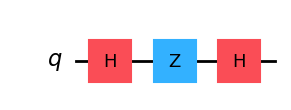

In [23]:
circuito_hzh = QuantumCircuit(1)
circuito_hzh.h(0) #Aplicamos primero H
circuito_hzh.z(0) #Aplicamos después Z
circuito_hzh.h(0) #Aplicamos finalmente H

matriz_hzh_qiskit = Operator(circuito_hzh).data #Recuperamos la matriz total del circuito

print("Matriz obtenida con Qiskit:\n", matriz_hzh_qiskit)
print("\n¿Coincide con HZH de NumPy?", np.allclose(matriz_hzh_qiskit, U_circuito_1))
print("¿Coincide con X?", np.allclose(matriz_hzh_qiskit, X))

display(circuito_hzh.draw("mpl"))

### Componer e Invertir Circuitos

`compose` nos permite aplicar un circuito después de otro. Si el primer circuito representa $U$ y el segundo representa $V$, la composición representa

$$
VU.
$$

`inverse` construye el circuito inverso. Para una matriz unitaria,

$$
U^{-1}=U^\dagger,
$$

por lo que

$$
U^{-1}U=I.
$$

Vamos a preparar un estado y después deshacer la preparación. El resultado debe regresar a $|0\rangle$.

Estado final: [ 1.+0.j -0.+0.j]
¿Regresamos a |0>? True


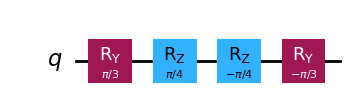

In [24]:
preparacion = QuantumCircuit(1, name="P")
preparacion.ry(np.pi/3, 0) #Aplicamos una rotación alrededor de Y
preparacion.rz(np.pi/4, 0) #Aplicamos una rotación alrededor de Z

ida_y_vuelta = preparacion.compose(preparacion.inverse()) #Aplicamos P y después su inversa
estado_ida_y_vuelta = Statevector.from_instruction(ida_y_vuelta) #Recuperamos el estado final

print("Estado final:", estado_ida_y_vuelta.data)
print("¿Regresamos a |0>?", np.allclose(estado_ida_y_vuelta.data, ket0))

display(ida_y_vuelta.draw("mpl"))

### Medir en las Bases $X$ y $Y$

Qiskit mide directamente en la base computacional, que es la base de eigenvectores de $Z$:

$$
\{|0\rangle,|1\rangle\}.
$$

Para medir en la base de $X$,

$$
\{|+\rangle,|-\rangle\},
$$

aplicamos $H$ antes de medir. Esto funciona porque

$$
H|+\rangle=|0\rangle,
\qquad
H|-\rangle=|1\rangle.
$$

Para medir en la base de $Y$, aplicamos primero $S^\dagger$ y después $H$. Estas operaciones transforman los eigenvectores de $Y$ en los estados de la base computacional.

Medición en Z: {'0': 514, '1': 486}
Medición en X: {'0': 514, '1': 486}
Medición en Y: {'0': 1000}


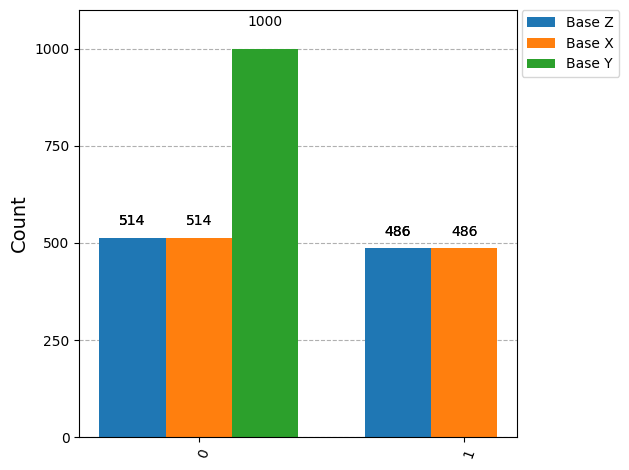

In [25]:
preparar_plus_i = QuantumCircuit(1)
preparar_plus_i.h(0)
preparar_plus_i.s(0) #Preparamos |+i>=(|0>+i|1>)/sqrt(2)

medir_z = preparar_plus_i.copy()
medir_z.measure_all() #Medimos directamente en la base Z

medir_x = preparar_plus_i.copy()
medir_x.h(0) #Cambiamos de la base X a la base Z
medir_x.measure_all()

medir_y = preparar_plus_i.copy()
medir_y.sdg(0) #Eliminamos la fase de la base Y
medir_y.h(0) #Cambiamos de la base X a la base Z
medir_y.measure_all()

conteos_z = simulador.run(medir_z, shots=1000, seed_simulator=9).result().get_counts()
conteos_x = simulador.run(medir_x, shots=1000, seed_simulator=9).result().get_counts()
conteos_y = simulador.run(medir_y, shots=1000, seed_simulator=9).result().get_counts()

print("Medición en Z:", conteos_z)
print("Medición en X:", conteos_x)
print("Medición en Y:", conteos_y)

plot_histogram([conteos_z, conteos_x, conteos_y], legend=["Base Z", "Base X", "Base Y"])

### Inspeccionar un Circuito

`depth()` nos dice cuántas capas de operaciones tiene un circuito y `count_ops()` cuenta cuántas veces aparece cada compuerta.

Estas herramientas no cambian el circuito. Solamente nos permiten observar su estructura y entender qué operaciones contiene antes de ejecutarlo.

In [26]:
print("Profundidad de HZH:", circuito_hzh.depth())
print("Operaciones de HZH:", circuito_hzh.count_ops())
print("\nProfundidad del circuito de medición en Y:", medir_y.depth())
print("Operaciones del circuito de medición en Y:", medir_y.count_ops())

Profundidad de HZH: 3
Operaciones de HZH: OrderedDict([('h', 2), ('z', 1)])

Profundidad del circuito de medición en Y: 5
Operaciones del circuito de medición en Y: OrderedDict([('h', 2), ('s', 1), ('sdg', 1), ('barrier', 1), ('measure', 1)])


## References

Las explicaciones, el código, los ejemplos, los ejercicios y la presentación pedagógica de este notebook fueron escritos por Benjamín Sánchez Hernández.

Para la teoría, la notación y los ejercicios se utilizaron como referencia las notas del curso:

1. *Lecture Notes 02 - Complex Numbers and Fields*, QC I, FC UNAM, agosto de 2026.
2. *Lecture Notes 03 - Matrices and Vector Spaces*, QC I, FC UNAM, agosto de 2026.
3. *Lecture Notes 04 - Dirac Notation*, QC I, FC UNAM, agosto de 2026.
4. *Lecture Notes 05 - Postulates of Quantum Mechanics and the Bell State Quantum Circuit*, QC I, FC UNAM, agosto de 2026.
5. *Matemáticas para computación cuántica - Sesión 1: Números complejos y exponencial compleja*.
6. *Matemáticas para computación cuántica - Sesión 2: Álgebra lineal esencial*.

Para la implementación se consultó la documentación oficial de NumPy y Qiskit:

- NumPy Linear Algebra: https://numpy.org/doc/stable/reference/routines.linalg.html
- NumPy `kron`: https://numpy.org/doc/stable/reference/generated/numpy.kron.html
- Qiskit `Statevector`: https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.quantum_info.Statevector
- Qiskit `Operator`: https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.quantum_info.Operator
- Qiskit bit ordering: https://quantum.cloud.ibm.com/docs/guides/bit-ordering
- Qiskit Aer `AerSimulator`: https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html